# Indic Embedding Language Alignment Benchmark — Colab Version

This notebook benchmarks Indic/multilingual embedding models for **cross-lingual semantic alignment**.

Main question:

> If two sentences mean the same thing in English and an Indic language, do their embeddings become close?

We test this using FLORES translation pairs and compute:

- **Positive cosine mean**: similarity of true translation pairs
- **Random cosine mean**: similarity of mismatched pairs
- **Cosine gap**: positive mean − random mean
- **Accuracy@1**: whether the correct translation is the nearest neighbor
- **Recall@5 / Recall@10 / MRR**

Start small with `QUICK_N = 100`, then increase to 250 or full devtest.


## 0. Colab GPU setup

In Colab, go to:

**Runtime → Change runtime type → Hardware accelerator → GPU → Save**

Then run the next cell.

In [ ]:
from pathlib import Path
import sys

for _candidate in (Path.cwd(), *Path.cwd().parents):
    _guard_dir = _candidate / "scripts"
    if (_guard_dir / "import_guard.py").exists():
        if str(_guard_dir) not in sys.path:
            sys.path.insert(0, str(_guard_dir))
        break
else:
    raise RuntimeError("Could not locate scripts/import_guard.py. Run this notebook from the WSAI workspace or copy the guard module alongside it.")

from import_guard import install_pandas_guards
install_pandas_guards()


In [ ]:
# Clean broken vision packages. We do not need these for text embeddings.
!pip -q uninstall -y torchvision torchaudio torchtext fastai timm -q

# Install only text/NLP packages.
# Do NOT install torch manually. Let Colab keep its own working GPU torch.
!pip -q install \
  "numpy==2.0.2" \
  "scipy==1.15.3" \
  "scikit-learn==1.6.1" \
  "transformers==4.48.3" \
  "sentence-transformers==3.4.1" \
  "accelerate==1.3.0" \
  "pandas==2.2.2" \
  "tqdm==4.67.1" \
  "matplotlib==3.10.0" \
  "pyyaml==6.0.2" \
  "sentencepiece==0.2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 124.9 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import scipy
import sklearn
import transformers
import sentence_transformers
import pandas as pd

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("transformers:", transformers.__version__)
print("sentence-transformers:", sentence_transformers.__version__)
print("pandas:", pd.__version__)

torch: 2.10.0+cu128
cuda available: True
numpy: 2.0.2
scipy: 1.15.3
sklearn: 1.6.1
transformers: 4.48.3
sentence-transformers: 3.4.1
pandas: 2.2.2


## 1. Install dependencies

Run this once per fresh Colab session. After installing, Colab may ask you to restart the runtime. If it does, restart and continue from the next cells.

## 2. Optional: mount Google Drive

This saves embeddings and CSV results permanently. If you do not mount Drive, results will stay only in the Colab runtime.

In [ ]:
from google.colab import drive
USE_DRIVE = True

if USE_DRIVE:
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/indic_embedding_benchmark'
else:
    BASE_DIR = '/content/indic_embedding_benchmark'

print('Saving outputs to:', BASE_DIR)

Mounted at /content/drive
Saving outputs to: /content/drive/MyDrive/indic_embedding_benchmark


## 3. Imports and configuration

First run only 100 examples. Once the notebook works, change:

```python
QUICK_N = 250
```

Later, for full devtest:

```python
QUICK_N = 0
```


In [ ]:
import gc
import os
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from datasets import load_dataset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

SEED = 42
SPLITS = ["dev", "devtest"]
QUICK_N = 0      # start with 100; later use 250; use 0 for full split
BATCH_SIZE = 32    # safe for Colab T4; increase to 32 if memory is fine
MAX_LENGTH = 128

OUTPUT_DIR = Path(BASE_DIR) / 'outputs' / 'flores_alignment_colab'
(OUTPUT_DIR / 'embeddings').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'errors').mkdir(parents=True, exist_ok=True)

LANGS = {
    'en': 'eng_Latn',
    'hi': 'hin_Deva',
    'bn': 'ben_Beng',
    'te': 'tel_Telu',
    'ta': 'tam_Taml',
    'ml': 'mal_Mlym',
}

# Start with 3 models if you want a fast first run.
# Then add the remaining models.
MODELS = [
    # Existing models
    {
        'name': 'labse',
        'hf_id': 'sentence-transformers/LaBSE',
        'kind': 'sentence_transformer'
    },
    {
        'name': 'mpnet_multilingual',
        'hf_id': 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
        'kind': 'sentence_transformer'
    },
    {
        'name': 'muril',
        'hf_id': 'google/muril-base-cased',
        'kind': 'hf_mean_pool'
    },
    {
        'name': 'indicbertv2_ss',
        'hf_id': 'ai4bharat/IndicBERTv2-SS',
        'kind': 'hf_mean_pool',
        'trust_remote_code': True
    },
    {
        'name': 'xlm_roberta_base',
        'hf_id': 'FacebookAI/xlm-roberta-base',
        'kind': 'hf_mean_pool'
    },

    # Added from papers we read

    # SBERT-style multilingual sentence-transformer baseline
    {
        'name': 'sbert_multilingual_minilm',
        'hf_id': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
        'kind': 'sentence_transformer'
    },

    # SimCSE original-style model
    # Mostly English, so use it as a paper baseline, not the strongest Indic model
    {
        'name': 'simcse_roberta_supervised',
        'hf_id': 'princeton-nlp/sup-simcse-roberta-base',
        'kind': 'hf_mean_pool'
    },

    # Multilingual SimCSE-style model, better choice for cross-lingual benchmark
    {
        'name': 'simcse_xlmr_multilingual',
        'hf_id': 'ZurichNLP/unsup-simcse-xlm-roberta-base',
        'kind': 'hf_mean_pool'
    },

    # Contriever: dense retrieval model
    # Mostly useful as retrieval baseline
    {
        'name': 'contriever',
        'hf_id': 'facebook/contriever',
        'kind': 'hf_mean_pool'
    },

    # mContriever: multilingual Contriever
    # More important for your Indic alignment benchmark
    {
        'name': 'mcontriever',
        'hf_id': 'facebook/mcontriever',
        'kind': 'hf_mean_pool'
    },
]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Output dir:', OUTPUT_DIR)

Device: cuda
Output dir: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab


## 4. Load FLORES parallel sentences

FLORES rows align by index across languages. So row `i` in English is the translation pair for row `i` in Hindi/Tamil/etc.

In [ ]:
from typing import Dict, List
from pathlib import Path
import urllib.request
import tarfile
import shutil
import os
FLORES_URL = "https://dl.fbaipublicfiles.com/nllb/flores200_dataset.tar.gz"
FLORES_CACHE_DIR = Path("/content/flores200_cache")

def download_file(url: str, output_path: Path):
    req = urllib.request.Request(
        url,
        headers={"User-Agent": "Mozilla/5.0"}
    )

    with urllib.request.urlopen(req) as response, open(output_path, "wb") as out_file:
        shutil.copyfileobj(response, out_file)


def ensure_flores200_downloaded(cache_dir: Path = FLORES_CACHE_DIR) -> Path:
    cache_dir.mkdir(parents=True, exist_ok=True)

    dataset_dir = cache_dir / "flores200_dataset"
    tar_path = cache_dir / "flores200_dataset.tar.gz"

    # If already extracted, use it directly
    if dataset_dir.exists():
        print("FLORES-200 already extracted.")
        return dataset_dir

    # Remove old broken zip/html file from previous attempt if present
    old_bad_zip = cache_dir / "flores200_dataset.zip"
    if old_bad_zip.exists():
        old_bad_zip.unlink()

    # Download tar.gz
    if not tar_path.exists():
        print("Downloading FLORES-200 tar.gz...")
        download_file(FLORES_URL, tar_path)

    # Safety check: if downloaded file is bad HTML, delete and stop clearly
    if not tarfile.is_tarfile(tar_path):
        with open(tar_path, "rb") as f:
            preview = f.read(300)
        tar_path.unlink()
        raise RuntimeError(
            "Downloaded file is not a tar.gz file. "
            "Maybe the redirect was blocked. Preview:\n"
            f"{preview[:300]}"
        )

    print("Extracting FLORES-200...")
    with tarfile.open(tar_path, "r:*") as tar:
        tar.extractall(cache_dir)

    if not dataset_dir.exists():
        candidates = list(cache_dir.rglob("flores200_dataset"))
        if not candidates:
            raise FileNotFoundError("Could not find extracted flores200_dataset folder.")
        dataset_dir = candidates[0]

    return dataset_dir


def load_flores_sentences(
    langs: Dict[str, str],
    split: str,
    quick_n: int
) -> Dict[str, List[str]]:

    flores_dir = ensure_flores200_downloaded()
    all_texts = {}

    for short, flores_code in langs.items():
        print(f"Loading {short} / {flores_code}")

        file_path = flores_dir / split / f"{flores_code}.{split}"

        if not file_path.exists():
            raise FileNotFoundError(f"Missing FLORES file: {file_path}")

        with open(file_path, "r", encoding="utf-8") as f:
            texts = [line.strip() for line in f if line.strip()]

        if quick_n and quick_n > 0:
            texts = texts[:quick_n]
        print(f"Loaded {short , len(texts)} sentences.")

        all_texts[short] = texts

    lengths = {lang: len(texts) for lang, texts in all_texts.items()}
    print("Loaded lengths:", lengths)

    if len(set(lengths.values())) != 1:
        raise ValueError(f"Language lengths are not equal: {lengths}")

    return all_texts


def load_flores_sentences_multi_split(
    langs: Dict[str, str],
    splits: List[str],
    quick_n: int
) -> Dict[str, List[str]]:

    flores_dir = ensure_flores200_downloaded()
    all_texts = {short: [] for short in langs}

    for split in splits:
        print(f"\nLoading split: {split}")

        for short, flores_code in langs.items():
            print(f"Loading {short} / {flores_code}")

            file_path = flores_dir / split / f"{flores_code}.{split}"

            if not file_path.exists():
                raise FileNotFoundError(f"Missing FLORES file: {file_path}")

            with open(file_path, "r", encoding="utf-8") as f:
                texts = [line.strip() for line in f if line.strip()]

            all_texts[short].extend(texts)
            print(f"Loaded {short}: {len(texts)} sentences from {split}")

    if quick_n and quick_n > 0:
        for short in all_texts:
            all_texts[short] = all_texts[short][:quick_n]

    lengths = {lang: len(texts) for lang, texts in all_texts.items()}
    print("\nTotal loaded lengths:", lengths)

    if len(set(lengths.values())) != 1:
        raise ValueError(f"Language lengths are not equal: {lengths}")

    return all_texts

texts_by_lang = load_flores_sentences_multi_split(LANGS, SPLITS, QUICK_N)

print("Example:")
print("EN:", texts_by_lang["en"][10])
print("HI:", texts_by_lang["hi"][10])

Extracting FLORES-200...


/tmp/ipykernel_1780/3841863524.py:54: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(cache_dir)



Loading split: dev
Loading en / eng_Latn
Loaded en: 997 sentences from dev
Loading hi / hin_Deva
Loaded hi: 997 sentences from dev
Loading bn / ben_Beng
Loaded bn: 997 sentences from dev
Loading te / tel_Telu
Loaded te: 997 sentences from dev
Loading ta / tam_Taml
Loaded ta: 997 sentences from dev
Loading ml / mal_Mlym
Loaded ml: 997 sentences from dev

Loading split: devtest
Loading en / eng_Latn
Loaded en: 1012 sentences from devtest
Loading hi / hin_Deva
Loaded hi: 1012 sentences from devtest
Loading bn / ben_Beng
Loaded bn: 1012 sentences from devtest
Loading te / tel_Telu
Loaded te: 1012 sentences from devtest
Loading ta / tam_Taml
Loaded ta: 1012 sentences from devtest
Loading ml / mal_Mlym
Loaded ml: 1012 sentences from devtest

Total loaded lengths: {'en': 2009, 'hi': 2009, 'bn': 2009, 'te': 2009, 'ta': 2009, 'ml': 2009}
Example:
EN: Around 11:29, the protest moved up Whitehall, past Trafalgar Square, along the Strand, passing by Aldwych and up Kingsway towards Holborn where t

## 5. Embedding helpers

Sentence-transformer models use their built-in pooling. Raw backbone models use attention-mask-aware mean pooling.

In [ ]:

@dataclass
class ModelSpec:
    name: str
    hf_id: str
    kind: str
    trust_remote_code: bool = False


def mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """
    Mean pooling:
    Takes token embeddings and averages only the real tokens,
    ignoring padding tokens.
    """
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


class Embedder:
    def __init__(self, spec: ModelSpec, device: str, max_length: int):
        self.spec = spec
        self.device = device
        self.max_length = max_length
        self.tokenizer = None
        self.model = None

        if spec.kind == "sentence_transformer":
            self._load_sentence_transformer()

        elif spec.kind == "hf_mean_pool":
            self._load_hf_mean_pool()

        else:
            raise ValueError(f"Unknown model kind: {spec.kind}")

    def _load_sentence_transformer(self):
        """
        First tries SentenceTransformer.
        If it fails because of missing pooling config,
        fallback to normal Hugging Face mean pooling.
        """
        try:
            from sentence_transformers import SentenceTransformer

            print(f"Loading as SentenceTransformer: {self.spec.hf_id}")

            self.model = SentenceTransformer(
                self.spec.hf_id,
                device=self.device,
                trust_remote_code=self.spec.trust_remote_code,
            )

            if self.device == "cuda":
                self.model = self.model.half()

            self.model_kind_used = "sentence_transformer"
            self.tokenizer = None

        except Exception as e:
            print(f"SentenceTransformer loading failed for {self.spec.name}")
            print(type(e).__name__, ":", e)
            print("Falling back to Hugging Face AutoModel + mean pooling...")

            self._load_hf_mean_pool()
            self.model_kind_used = "hf_mean_pool_fallback"

    def _load_hf_mean_pool(self):
        """
        Loads model using Hugging Face AutoModel and applies mean pooling manually.
        This is used for MuRIL, XLM-R, IndicBERTv2, Contriever, mContriever, SimCSE, etc.
        """
        from transformers import AutoModel, AutoTokenizer

        print(f"Loading as HF mean-pool model: {self.spec.hf_id}")

        self.tokenizer = AutoTokenizer.from_pretrained(
            self.spec.hf_id,
            trust_remote_code=self.spec.trust_remote_code,
        )

        dtype = torch.float16 if self.device == "cuda" else torch.float32

        try:
            self.model = AutoModel.from_pretrained(
                self.spec.hf_id,
                trust_remote_code=self.spec.trust_remote_code,
                torch_dtype=dtype,
            )

        except Exception as e:
            print(f"Normal AutoModel loading failed for {self.spec.name}")
            print(type(e).__name__, ":", e)
            print("Retrying without torch_dtype...")

            self.model = AutoModel.from_pretrained(
                self.spec.hf_id,
                trust_remote_code=self.spec.trust_remote_code,
            )

        self.model.to(self.device)
        self.model.eval()
        self.model_kind_used = "hf_mean_pool"

    @torch.no_grad()
    def encode(self, texts: List[str], batch_size: int) -> np.ndarray:
        """
        Encodes a list of texts into normalized embeddings.
        """
        if self.model_kind_used == "sentence_transformer":
            emb = self.model.encode(
                texts,
                batch_size=batch_size,
                convert_to_numpy=True,
                normalize_embeddings=True,
                show_progress_bar=True,
            )
            return emb.astype("float32")

        all_embeddings = []

        for start in tqdm(
            range(0, len(texts), batch_size),
            desc=f"Encoding {self.spec.name}"
        ):
            batch = texts[start:start + batch_size]

            encoded = self.tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt",
            )

            encoded = {k: v.to(self.device) for k, v in encoded.items()}

            outputs = self.model(**encoded)

            pooled = mean_pool(
                outputs.last_hidden_state,
                encoded["attention_mask"]
            )

            pooled = F.normalize(pooled, p=2, dim=1)

            all_embeddings.append(
                pooled.detach().cpu().float().numpy()
            )

        return np.vstack(all_embeddings).astype("float32")


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 6. Metric functions

In [ ]:
def compute_retrieval_metrics(src_emb: np.ndarray, tgt_emb: np.ndarray, top_ks: Tuple[int, ...] = (1, 5, 10)) -> Dict[str, float]:
    sim = np.matmul(src_emb, tgt_emb.T)
    n = sim.shape[0]
    sorted_idx = np.argsort(-sim, axis=1)
    ranks = np.empty(n, dtype=np.int64)

# For each source sentence i, the correct target translation is also at index i
# because FLORES is index-aligned: English row i ↔ Hindi/Tamil/etc. row i.
# sorted_idx[i] contains target sentence indexes sorted from most similar to least similar.
# This loop finds where the correct target index i appears in that sorted list.
# That position + 1 is the rank:
# rank 1 = correct translation is the nearest neighbour
# rank 2 = correct translation is the second nearest neighbour
# rank 10 = correct translation is the tenth nearest neighbour

    for i in range(n):
        ranks[i] = int(np.where(sorted_idx[i] == i)[0][0]) + 1

    out = {
        'mrr': float(np.mean(1.0 / ranks)),
        'mean_rank': float(np.mean(ranks)),
        'median_rank': float(np.median(ranks)),
    }
    for k in top_ks:
        out[f'recall_at_{k}'] = float(np.mean(ranks <= k))
    out['accuracy_at_1'] = out['recall_at_1']
    return out


def compute_cosine_gap(src_emb: np.ndarray, tgt_emb: np.ndarray, seed: int = 42) -> Dict[str, float]:
    rng = np.random.default_rng(seed)
    n = src_emb.shape[0]
    pos = np.sum(src_emb * tgt_emb, axis=1)

    neg_idx = rng.permutation(n)
    for i in range(n):
        if neg_idx[i] == i:
            neg_idx[i] = (neg_idx[i] + 1) % n
    neg = np.sum(src_emb * tgt_emb[neg_idx], axis=1)

    return {
        'positive_cosine_mean': float(np.mean(pos)),
        'positive_cosine_std': float(np.std(pos)),
        'random_cosine_mean': float(np.mean(neg)),
        'random_cosine_std': float(np.std(neg)),
        'cosine_gap': float(np.mean(pos) - np.mean(neg)),
    }


def collect_errors(src_texts, tgt_texts, src_emb, tgt_emb, n_examples=25):
    sim = np.matmul(src_emb, tgt_emb.T)
    pred_idx = np.argmax(sim, axis=1)
    rows = []
    for i, p in enumerate(pred_idx):
        if p != i:
            rows.append({
                'row_id': i,
                'source_text': src_texts[i],
                'gold_translation': tgt_texts[i],
                'predicted_neighbor': tgt_texts[p],
                'gold_cosine': float(sim[i, i]),
                'predicted_cosine': float(sim[i, p]),
                'margin_pred_minus_gold': float(sim[i, p] - sim[i, i]),
            })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values('margin_pred_minus_gold', ascending=False).head(n_examples)

## 7. Run benchmark

This cell saves embeddings after every model/language. If Colab disconnects, rerun the notebook and it will reuse cached `.npy` files.

In [ ]:
# Create a clean dataset tag for cache filenames.
# Works for both single split and multi-split setup.
if "SPLITS" in globals():
    SPLIT_TAG = "_".join(SPLITS)   # example: dev_devtest
else:
    SPLIT_TAG = SPLIT              # example: devtest

# If QUICK_N = 100, tag becomes 100.
# If QUICK_N = 0, tag becomes full.
N_TAG = QUICK_N if QUICK_N and QUICK_N > 0 else "full"

print("Using split tag:", SPLIT_TAG)
print("Using N tag:", N_TAG)

all_rows = []

for model_dict in MODELS:
    spec = ModelSpec(**model_dict)
    print(f"\n===== Model: {spec.name} | {spec.hf_id} =====")

    embedder = None

    try:
        # Load current embedding model
        embedder = Embedder(spec, DEVICE, MAX_LENGTH)

        # This dictionary stores embeddings for each language.
        # Example:
        # emb_by_lang["en"] = English embeddings
        # emb_by_lang["hi"] = Hindi embeddings
        emb_by_lang = {}

        # ------------------------------------------------------------
        # STEP 1: Encode every language once for the current model
        # ------------------------------------------------------------
        for lang, texts in texts_by_lang.items():

            cache_path = (
                OUTPUT_DIR
                / "embeddings"
                / f"{spec.name}_{lang}_{SPLIT_TAG}_n{N_TAG}_l{MAX_LENGTH}.npy"
            )

            # If embeddings already exist, load them.
            # This saves time when rerunning Colab.
            if cache_path.exists():
                print("Loading cached:", cache_path.name)
                emb = np.load(cache_path)

                # Safety check:
                # If old cache has a different number of sentences,
                # recompute embeddings.
                if emb.shape[0] != len(texts):
                    print(
                        f"Cache size mismatch for {cache_path.name}. "
                        f"Expected {len(texts)}, got {emb.shape[0]}. Recomputing..."
                    )
                    emb = embedder.encode(texts, batch_size=BATCH_SIZE)
                    np.save(cache_path, emb)
                    print("Saved corrected cache:", cache_path.name)

            # If embeddings do not exist, create and save them.
            else:
                emb = embedder.encode(texts, batch_size=BATCH_SIZE)
                np.save(cache_path, emb)
                print("Saved:", cache_path.name)

            emb_by_lang[lang] = emb

            print(
                f"Embedding stored | model={spec.name} | lang={lang} | "
                f"texts={len(texts)} | shape={emb.shape}"
            )

        # ------------------------------------------------------------
        # STEP 2: Evaluate every language against every other language
        # ------------------------------------------------------------
        # Example pairs:
        # en -> hi, hi -> en, hi -> ta, ta -> hi, bn -> ml, etc.
        # We skip same-language pairs like en -> en or hi -> hi.
        for src_lang in LANGS:
            for tgt_lang in LANGS:

                if src_lang == tgt_lang:
                    continue

                pair = f"{src_lang}-{tgt_lang}"

                src_emb = emb_by_lang[src_lang]
                tgt_emb = emb_by_lang[tgt_lang]

                # Sanity check: source and target should have same number of rows
                # because FLORES is index-aligned.
                if src_emb.shape[0] != tgt_emb.shape[0]:
                    raise ValueError(
                        f"Embedding length mismatch for {pair}: "
                        f"{src_emb.shape[0]} vs {tgt_emb.shape[0]}"
                    )

                # Cosine gap:
                # checks whether correct translations are closer than random wrong pairs.
                gap = compute_cosine_gap(src_emb, tgt_emb, SEED)

                # Retrieval metrics:
                # checks whether the correct translation is nearest / top-5 / top-10.
                retrieval = compute_retrieval_metrics(src_emb, tgt_emb)

                row = {
                    "model": spec.name,
                    "hf_id": spec.hf_id,
                    "source_language": src_lang,
                    "target_language": tgt_lang,
                    "language_pair": pair,
                    "split": SPLIT_TAG,
                    "n_examples": len(texts_by_lang[src_lang]),
                    **gap,
                    **retrieval,
                }

                all_rows.append(row)

                print(
                    pair,
                    "Acc@1:", round(row["accuracy_at_1"], 4),
                    "Recall@10:", round(row["recall_at_10"], 4),
                    "MRR:", round(row["mrr"], 4),
                    "Cosine gap:", round(row["cosine_gap"], 4)
                )

                # Save examples where the model chose the wrong nearest neighbour.
                errors = collect_errors(
                    texts_by_lang[src_lang],
                    texts_by_lang[tgt_lang],
                    src_emb,
                    tgt_emb,
                    n_examples=25,
                )

                error_path = (
                    OUTPUT_DIR
                    / "errors"
                    / f"{spec.name}_{pair}_{SPLIT_TAG}_n{N_TAG}_errors.csv"
                )

                errors.to_csv(error_path, index=False)

    except Exception as e:
        print("FAILED model:", spec.name)
        print(type(e).__name__, ":", e)
        print("Skipping this model and moving to the next one.")

    finally:
        # Delete model from memory before loading next model.
        if embedder is not None:
            del embedder
        clear_memory()


# ------------------------------------------------------------
# STEP 3: Save full metrics table
# ------------------------------------------------------------
metrics_df = pd.DataFrame(all_rows)

if metrics_df.empty:
    raise ValueError(
        "No model produced results. This is likely an environment/import issue, "
        "or all models failed before metrics were computed."
    )

metrics_path = OUTPUT_DIR / f"flores_alignment_metrics_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.csv"
metrics_df.to_csv(metrics_path, index=False)

print("\nSaved metrics:", metrics_path)
print("metrics_df shape:", metrics_df.shape)

metrics_df.head()

Using split tag: dev_devtest
Using N tag: full

===== Model: labse | sentence-transformers/LaBSE =====
Loading as SentenceTransformer: sentence-transformers/LaBSE


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Encoding mcontriever:   0%|          | 0/63 [00:00<?, ?it/s]

Saved: mcontriever_ta_dev_devtest_nfull_l128.npy
Embedding stored | model=mcontriever | lang=ta | texts=2009 | shape=(2009, 768)


Encoding mcontriever:   0%|          | 0/63 [00:00<?, ?it/s]

Saved: mcontriever_ml_dev_devtest_nfull_l128.npy
Embedding stored | model=mcontriever | lang=ml | texts=2009 | shape=(2009, 768)
en-hi Acc@1: 0.4345 Recall@10: 0.773 MRR: 0.5528 Cosine gap: 0.1499
en-bn Acc@1: 0.6511 Recall@10: 0.9034 MRR: 0.7401 Cosine gap: 0.1862
en-te Acc@1: 0.7213 Recall@10: 0.9467 MRR: 0.8036 Cosine gap: 0.2017
en-ta Acc@1: 0.2877 Recall@10: 0.5789 MRR: 0.3898 Cosine gap: 0.1147
en-ml Acc@1: 0.2056 Recall@10: 0.4853 MRR: 0.2973 Cosine gap: 0.0928
hi-en Acc@1: 0.6242 Recall@10: 0.8532 MRR: 0.7066 Cosine gap: 0.1499
hi-bn Acc@1: 0.4828 Recall@10: 0.7501 MRR: 0.5757 Cosine gap: 0.1669
hi-te Acc@1: 0.5351 Recall@10: 0.7909 MRR: 0.6254 Cosine gap: 0.1689
hi-ta Acc@1: 0.324 Recall@10: 0.6172 MRR: 0.4228 Cosine gap: 0.1373
hi-ml Acc@1: 0.2832 Recall@10: 0.559 MRR: 0.3777 Cosine gap: 0.1191
bn-en Acc@1: 0.8059 Recall@10: 0.9482 MRR: 0.8605 Cosine gap: 0.1858
bn-hi Acc@1: 0.4505 Recall@10: 0.7561 MRR: 0.5595 Cosine gap: 0.1668
bn-te Acc@1: 0.7656 Recall@10: 0.9293 MRR: 0.8

,model,hf_id,source_language,target_language,language_pair,split,n_examples,positive_cosine_mean,positive_cosine_std,random_cosine_mean,random_cosine_std,cosine_gap,mrr,mean_rank,median_rank,recall_at_1,recall_at_5,recall_at_10,accuracy_at_1
0,labse,sentence-transformers/LaBSE,en,hi,en-hi,dev_devtest,2009,0.854995,0.049602,0.214217,0.080001,0.640778,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
1,labse,sentence-transformers/LaBSE,en,bn,en-bn,dev_devtest,2009,0.853945,0.050604,0.197645,0.079664,0.656300,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
2,labse,sentence-transformers/LaBSE,en,te,en-te,dev_devtest,2009,0.863120,0.054041,0.200753,0.080666,0.662366,0.998756,2.624689,1.0,0.998507,0.999004,0.999004,0.998507
3,labse,sentence-transformers/LaBSE,en,ta,en-ta,dev_devtest,2009,0.849143,0.051303,0.201337,0.078818,0.647806,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
4,labse,sentence-transformers/LaBSE,en,ml,en-ml,dev_devtest,2009,0.853375,0.054297,0.185039,0.080308,0.668337,0.999256,1.103036,1.0,0.999004,0.999502,0.999502,0.999004


In [ ]:
metrics_df

## 8. Model summary table

In [ ]:
print(metrics_df.shape)
print(metrics_df.columns.tolist())
print(metrics_df.head())

# 6 × 5 = 30 language pairs per model

# So if you run 5 models:

# 5 × 30 = 150 rows in metrics_df

(300, 19)
['model', 'hf_id', 'source_language', 'target_language', 'language_pair', 'split', 'n_examples', 'positive_cosine_mean', 'positive_cosine_std', 'random_cosine_mean', 'random_cosine_std', 'cosine_gap', 'mrr', 'mean_rank', 'median_rank', 'recall_at_1', 'recall_at_5', 'recall_at_10', 'accuracy_at_1']
   model                        hf_id source_language target_language  \
0  labse  sentence-transformers/LaBSE              en              hi   
1  labse  sentence-transformers/LaBSE              en              bn   
2  labse  sentence-transformers/LaBSE              en              te   
3  labse  sentence-transformers/LaBSE              en              ta   
4  labse  sentence-transformers/LaBSE              en              ml   

  language_pair        split  n_examples  positive_cosine_mean  \
0         en-hi  dev_devtest        2009              0.854995   
1         en-bn  dev_devtest        2009              0.853945   
2         en-te  dev_devtest        2009              

In [ ]:
# ------------------------------------------------------------
# 1. Overall model summary
# ------------------------------------------------------------
# This averages each model's performance across ALL language pairs.
# Example: labse average over en-hi, hi-en, ta-ml, ml-ta, etc.

summary = (
    metrics_df
    .groupby("model")[["accuracy_at_1", "recall_at_10", "mrr", "cosine_gap"]]
    .mean()
    .sort_values("accuracy_at_1", ascending=False)
)

summary_path = OUTPUT_DIR / f"model_summary_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.csv"
summary.to_csv(summary_path)

print("Saved summary:", summary_path)
display(summary)

Saved summary: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/model_summary_ALL_PAIRS_dev_devtest_nfull.csv


,accuracy_at_1,recall_at_10,mrr,cosine_gap
model,,,,
labse,0.998739,0.999386,0.999042,0.591848
mpnet_multilingual,0.871993,0.961440,0.905245,0.614066
muril,0.776074,0.918799,0.827152,0.003349
simcse_xlmr_multilingual,0.534644,0.803020,0.627809,0.332819
mcontriever,0.450307,0.706786,0.539515,0.146876
sbert_multilingual_minilm,0.225867,0.316376,0.258052,0.202356
xlm_roberta_base,0.214153,0.455550,0.296246,0.001245
contriever,0.060577,0.122997,0.084276,0.036423
indicbertv2_ss,0.053725,0.069620,0.061199,0.007581


In [ ]:
# ------------------------------------------------------------
# 2. Detailed language-pair summary
# ------------------------------------------------------------
# This keeps source and target languages separate.
# Useful for checking which direction is strong or weak.
# Example: hi -> ta may differ from ta -> hi.

pair_summary = (
    metrics_df
    .groupby(["model", "source_language", "target_language", "language_pair"])[
        ["accuracy_at_1", "recall_at_10", "mrr", "cosine_gap"]
    ]
    .mean()
    .reset_index()
    .sort_values(["model", "accuracy_at_1"], ascending=[True, False])
)

pair_summary_path = OUTPUT_DIR / f"language_pair_summary_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.csv"
pair_summary.to_csv(pair_summary_path, index=False)

print("Saved pair summary:", pair_summary_path)
display(pair_summary.head(30))

Saved pair summary: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/language_pair_summary_ALL_PAIRS_dev_devtest_nfull.csv


,model,source_language,target_language,language_pair,accuracy_at_1,recall_at_10,mrr,cosine_gap
28,contriever,te,ml,te-ml,0.178696,0.293678,0.220241,0.104661
19,contriever,ml,te,ml-te,0.175709,0.288701,0.216173,0.103378
9,contriever,en,te,en-te,0.115480,0.208561,0.149028,0.040176
24,contriever,ta,te,ta-te,0.103036,0.176705,0.130743,0.055629
23,contriever,ta,ml,ta-ml,0.099552,0.180189,0.128132,0.057597
26,contriever,te,en,te-en,0.086112,0.146839,0.108883,0.039928
7,contriever,en,ml,en-ml,0.077651,0.160777,0.108888,0.024818
8,contriever,en,ta,en-ta,0.070682,0.152315,0.099865,0.021913
6,contriever,en,hi,en-hi,0.063216,0.125436,0.087899,0.016594
13,contriever,hi,ta,hi-ta,0.061722,0.119462,0.085242,0.028830


## 9. Plot Accuracy@1

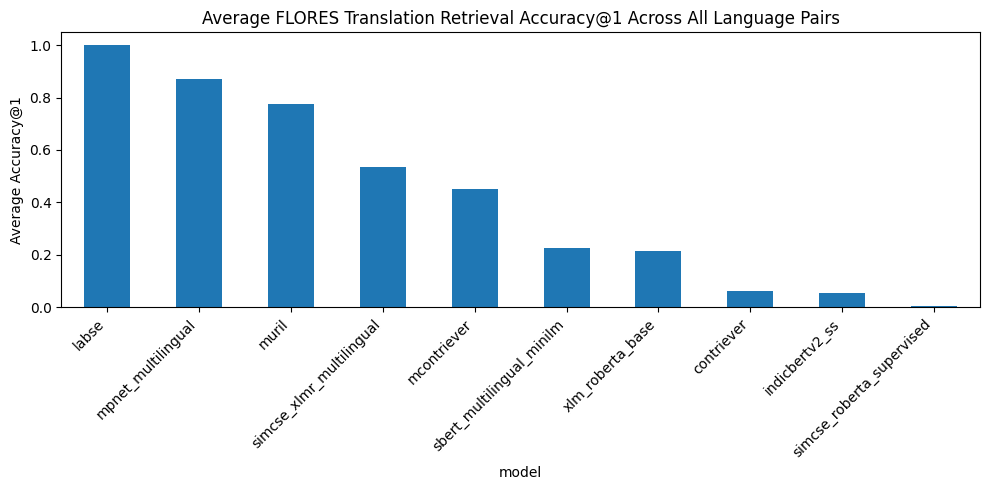

Saved plot: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/average_accuracy_at_1_ALL_PAIRS_dev_devtest_nfull.png


In [ ]:
# ------------------------------------------------------------
# 3. Plot average Accuracy@1 by model
# ------------------------------------------------------------
# Since all-pairs has many language pairs, plotting every pair
# in one bar chart becomes too crowded.
# So this plot shows average Accuracy@1 per model.

model_avg_acc = (
    metrics_df
    .groupby("model")["accuracy_at_1"]
    .mean()
    .sort_values(ascending=False)
)

ax = model_avg_acc.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("Average Accuracy@1")
ax.set_title("Average FLORES Translation Retrieval Accuracy@1 Across All Language Pairs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = OUTPUT_DIR / f"average_accuracy_at_1_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)

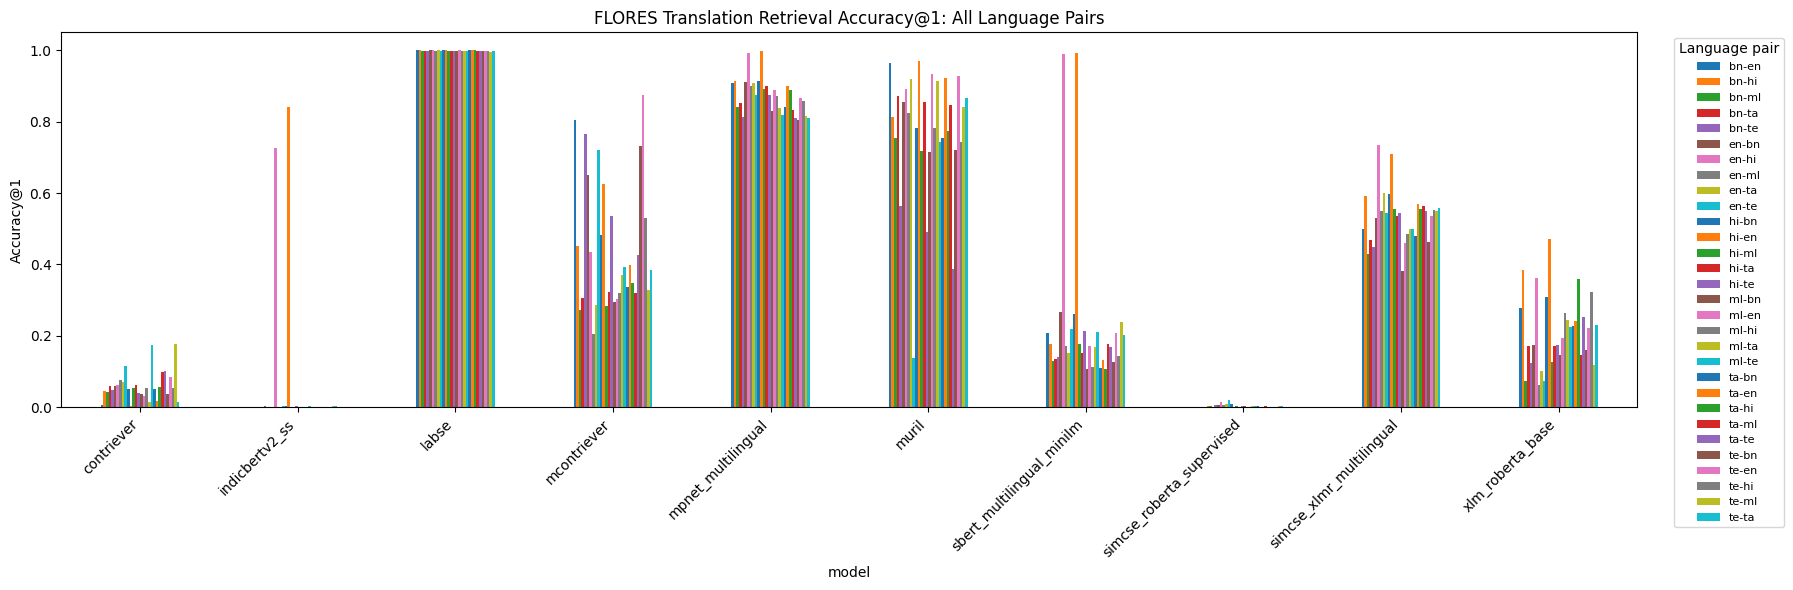

Saved plot: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/accuracy_at_1_by_model_ALL_PAIRS_dev_devtest_nfull.png


In [ ]:
# ------------------------------------------------------------
# 4. Optional: plot all language pairs for each model
# ------------------------------------------------------------
# This can be crowded, but useful when you want to inspect
# every source-target direction.

pivot = metrics_df.pivot(
    index="model",
    columns="language_pair",
    values="accuracy_at_1"
)

ax = pivot.plot(kind="bar", figsize=(18, 6))
ax.set_ylabel("Accuracy@1")
ax.set_title("FLORES Translation Retrieval Accuracy@1: All Language Pairs")
ax.legend(title="Language pair", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = OUTPUT_DIR / f"accuracy_at_1_by_model_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)

In [ ]:
# ------------------------------------------------------------
# 5. Best and worst language pairs per model
# ------------------------------------------------------------
# This helps you quickly see where each model works well
# and where it fails.

best_pairs = (
    metrics_df
    .sort_values(["model", "accuracy_at_1"], ascending=[True, False])
    .groupby("model")
    .head(5)
)

worst_pairs = (
    metrics_df
    .sort_values(["model", "accuracy_at_1"], ascending=[True, True])
    .groupby("model")
    .head(5)
)

best_pairs_path = OUTPUT_DIR / f"best_language_pairs_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.csv"
worst_pairs_path = OUTPUT_DIR / f"worst_language_pairs_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.csv"

best_pairs.to_csv(best_pairs_path, index=False)
worst_pairs.to_csv(worst_pairs_path, index=False)

print("Saved best pairs:", best_pairs_path)
display(best_pairs[["model", "language_pair", "accuracy_at_1", "recall_at_10", "mrr", "cosine_gap"]])

print("Saved worst pairs:", worst_pairs_path)
display(worst_pairs[["model", "language_pair", "accuracy_at_1", "recall_at_10", "mrr", "cosine_gap"]])

Saved best pairs: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/best_language_pairs_ALL_PAIRS_dev_devtest_nfull.csv


,model,language_pair,accuracy_at_1,recall_at_10,mrr,cosine_gap
259,contriever,te-ml,0.178696,0.293678,0.220241,0.104661
268,contriever,ml-te,0.175709,0.288701,0.216173,0.103378
242,contriever,en-te,0.115480,0.208561,0.149028,0.040176
263,contriever,ta-te,0.103036,0.176705,0.130743,0.055629
264,contriever,ta-ml,0.099552,0.180189,0.128132,0.057597
95,indicbertv2_ss,hi-en,0.840717,0.954704,0.880295,0.080205
90,indicbertv2_ss,en-hi,0.726232,0.851170,0.770634,0.080250
109,indicbertv2_ss,te-ml,0.003484,0.021901,0.013032,0.004672
118,indicbertv2_ss,ml-te,0.003484,0.015431,0.009834,0.004579
97,indicbertv2_ss,hi-te,0.002987,0.009457,0.006732,0.002456


Saved worst pairs: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/worst_language_pairs_ALL_PAIRS_dev_devtest_nfull.csv


,model,language_pair,accuracy_at_1,recall_at_10,mrr,cosine_gap
245,contriever,hi-en,0.004480,0.018915,0.013124,0.016553
250,contriever,bn-en,0.006471,0.028870,0.016870,0.014461
258,contriever,te-ta,0.013937,0.059233,0.033329,0.056722
269,contriever,ml-ta,0.013937,0.062718,0.033635,0.058320
260,contriever,ta-en,0.017919,0.056745,0.033198,0.021529
100,indicbertv2_ss,bn-en,0.000000,0.011946,0.005091,0.002738
102,indicbertv2_ss,bn-te,0.000498,0.005973,0.004910,0.002660
107,indicbertv2_ss,te-bn,0.000498,0.007466,0.004780,0.002462
110,indicbertv2_ss,ta-en,0.000498,0.005973,0.004390,0.001568
111,indicbertv2_ss,ta-hi,0.000498,0.006969,0.005035,0.000957


## 10. Inspect error examples

This is useful for your report. It shows where the model chose the wrong nearest translation.

In [ ]:
# ------------------------------------------------------------
# 6. Inspect error examples
# ------------------------------------------------------------
# Error files contain cases where the model selected the wrong nearest neighbour.

import glob

error_files = sorted(glob.glob(str(OUTPUT_DIR / "errors" / f"*_{SPLIT_TAG}_n{N_TAG}_errors.csv")))

print("Number of error files:", len(error_files))

print("\nFirst 10 error files:")
for path in error_files[:10]:
    print(path)

# Change this index to inspect another model/language pair.
ERROR_FILE_INDEX = 0

if error_files:
    sample_error_path = error_files[ERROR_FILE_INDEX]
    print("\nShowing errors from:", sample_error_path)

    sample_errors = pd.read_csv(sample_error_path)
    display(sample_errors.head(10))
else:
    print("No error files found.")

Number of error files: 300

First 10 error files:
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_bn-en_dev_devtest_nfull_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_bn-hi_dev_devtest_nfull_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_bn-ml_dev_devtest_nfull_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_bn-ta_dev_devtest_nfull_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_bn-te_dev_devtest_nfull_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_en-bn_dev_devtest_nfull_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_en-hi_dev_devtest_nfull_errors.csv
/content/drive/MyDr

,row_id,source_text,gold_translation,predicted_neighbor,gold_cosine,predicted_cosine,margin_pred_minus_gold
0,1682,কার্যত কোনও ভ্রমণের বিবরণ শেয়ার করে নেওয়া ভবি...,Sharing a field trip virtually is also a great...,Lakkha Singh presented the chhappan bhog bhaja...,0.157069,0.481324,0.324255
1,939,এ ব্যাপারে নিশ্চিত হও যে তুমি জানো ভেতরে কি আন...,Make sure you know what you can and cannot bri...,Lakkha Singh presented the chhappan bhog bhaja...,0.163021,0.481199,0.318178
2,784,অনেক বিদেশী প্রাণী আছে যেগুলো সহজে খুজে পাওয়া ...,"Many exotic animals are hard to find, and park...",Lakkha Singh presented the chhappan bhog bhaja...,0.139995,0.451850,0.311856
3,672,ফ্যান্টম রাঞ্চ সংলগ্ন ব্রাইট অ্যাঞ্জেল ক্যাম্প...,"Space for the most popular areas, such as the ...",Lakkha Singh presented the chhappan bhog bhaja...,0.120127,0.431556,0.311429
4,480,"অ্যাকর্ডিয়নে, উচ্চস্বরে শব্দ শুনতে নীচে জোরে ...","On the accordion, to get extra volume, you use...",The Sundarbans has been declared a UNESCO Worl...,0.176081,0.482775,0.306695
5,554,"প্রয়োজনমত জিনিস কেনা যেতে পারে, কিন্তু বেশিরভা...","Products can be purchased as needed, but most ...",Lakkha Singh presented the chhappan bhog bhaja...,0.179704,0.477303,0.297599
6,824,"ওয়েবসাইট হোক শপ উইন্ডো, এজেন্ট কী ধরনের ট্রিপ ...",Take a look at what trips the agent is promoti...,The Sundarbans has been declared a UNESCO Worl...,0.150046,0.446532,0.296487
7,1650,ভুত্বকটি পাতলা বলে ভূত্বকের কাছে আরো অনেক মারি...,There may be more maria on the near side becau...,Lakkha Singh presented the chhappan bhog bhaja...,0.164013,0.459581,0.295569
8,825,"আপনি যদি ছোট ভাবে, প্রয়োজনীয়তার জন্য, জীবনযা...","If you want to see the world on the cheap, for...",The Sundarbans has been declared a UNESCO Worl...,0.177693,0.468139,0.290446
9,714,যে এজেন্টের মাধ্যমে তুমি বরাদ্ধ করো নিশ্চিত হও...,Be sure the agent through whom you book is a G...,Lakkha Singh presented the chhappan bhog bhaja...,0.170149,0.457451,0.287302


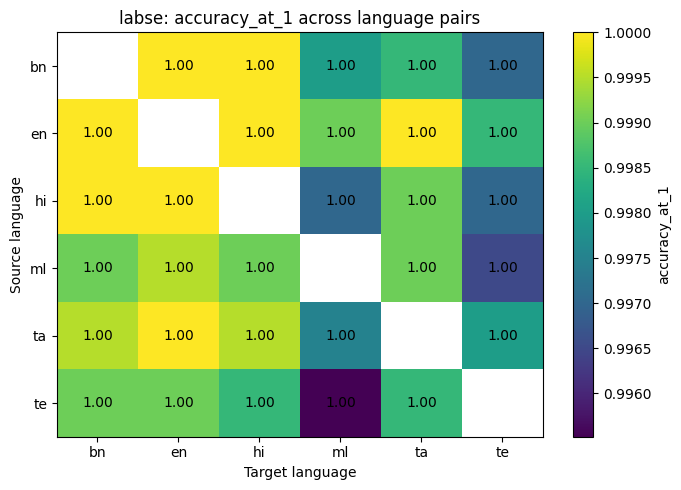

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/labse_accuracy_at_1_heatmap_dev_devtest_nfull.png


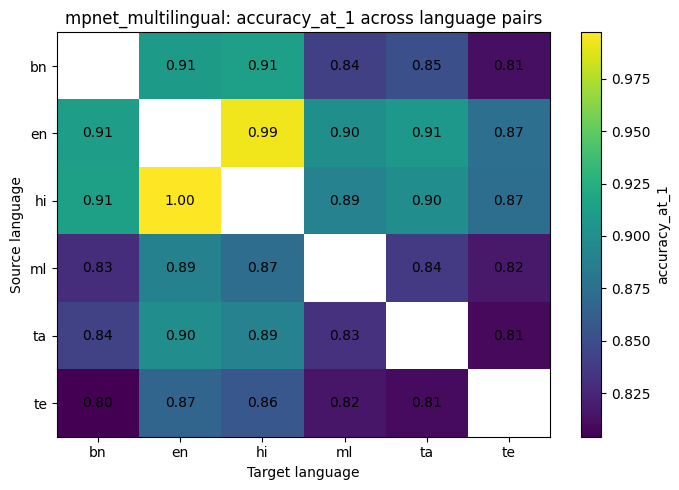

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/mpnet_multilingual_accuracy_at_1_heatmap_dev_devtest_nfull.png


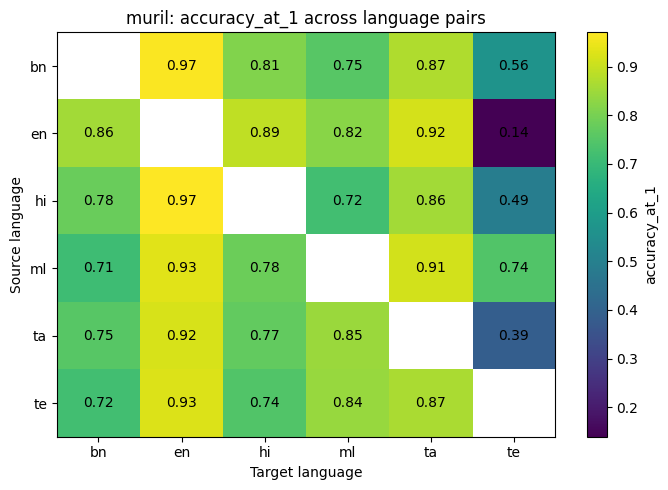

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/muril_accuracy_at_1_heatmap_dev_devtest_nfull.png


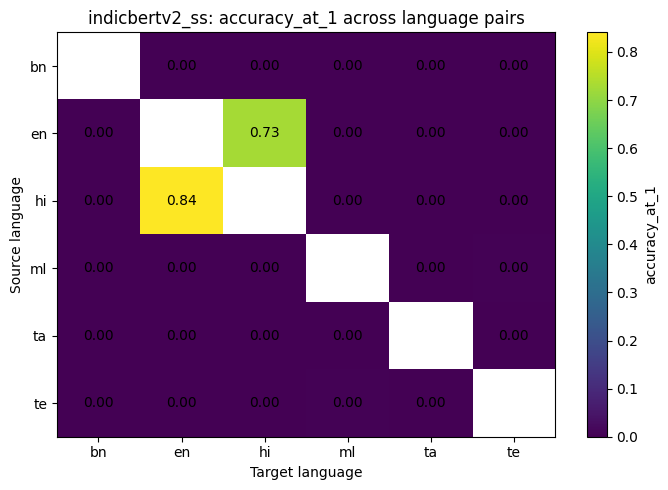

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/indicbertv2_ss_accuracy_at_1_heatmap_dev_devtest_nfull.png


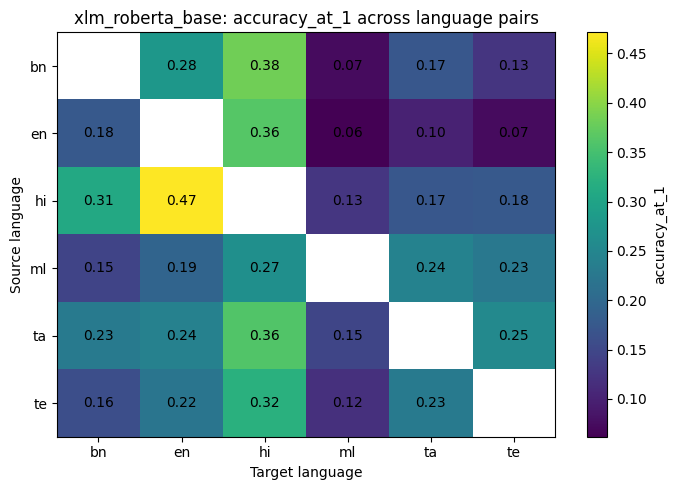

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/xlm_roberta_base_accuracy_at_1_heatmap_dev_devtest_nfull.png


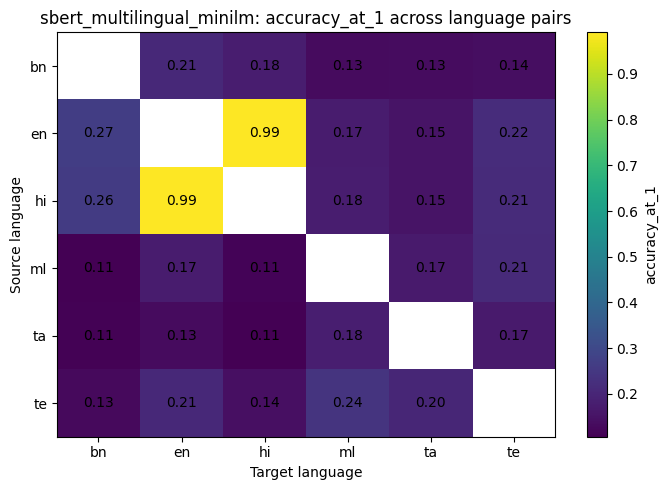

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/sbert_multilingual_minilm_accuracy_at_1_heatmap_dev_devtest_nfull.png


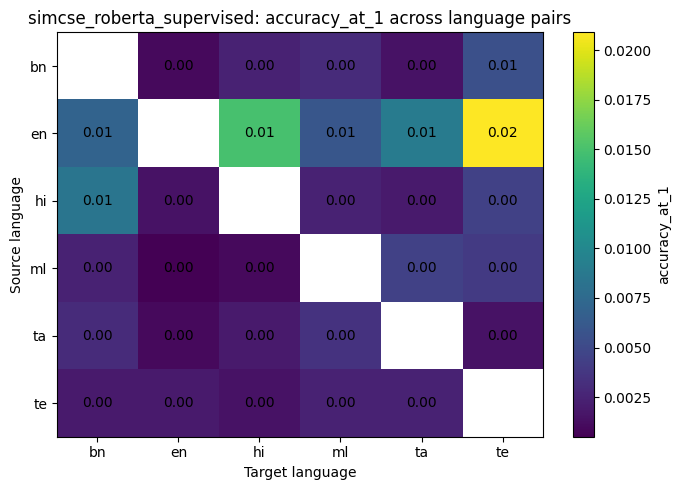

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/simcse_roberta_supervised_accuracy_at_1_heatmap_dev_devtest_nfull.png


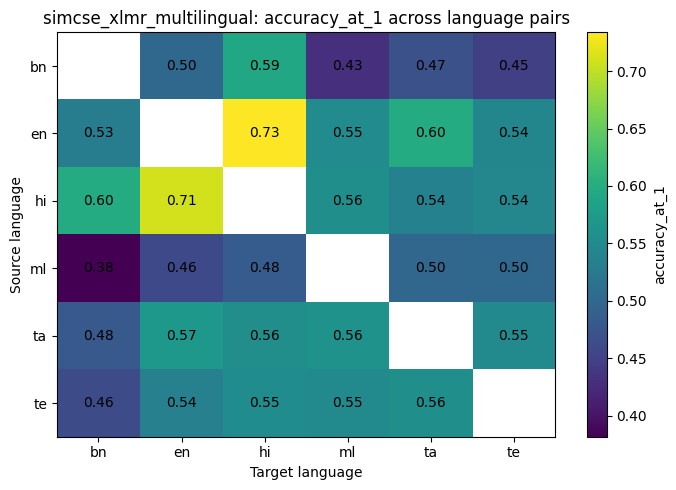

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/simcse_xlmr_multilingual_accuracy_at_1_heatmap_dev_devtest_nfull.png


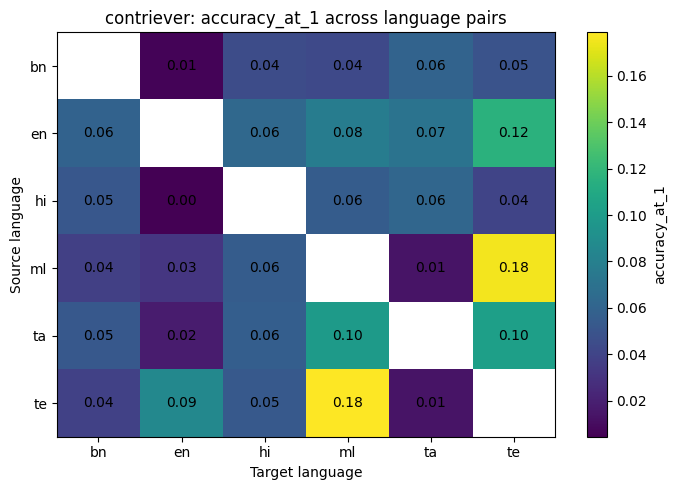

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/contriever_accuracy_at_1_heatmap_dev_devtest_nfull.png


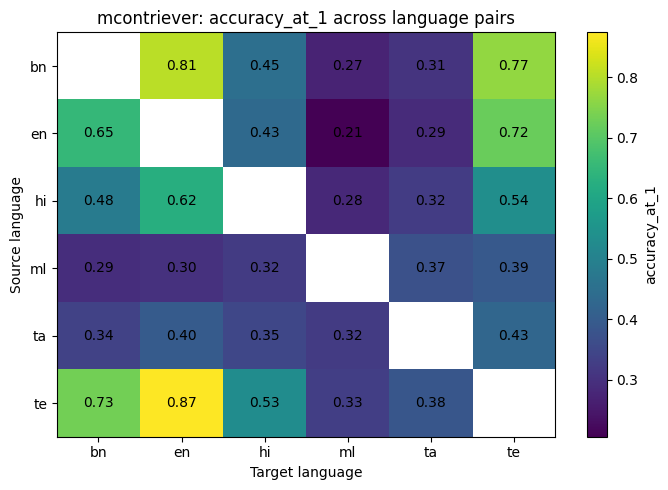

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/mcontriever_accuracy_at_1_heatmap_dev_devtest_nfull.png


In [ ]:
def plot_model_heatmap(metrics_df, model_name, metric="accuracy_at_1"):
    model_df = metrics_df[metrics_df["model"] == model_name]

    heatmap_data = model_df.pivot(
        index="source_language",
        columns="target_language",
        values=metric
    )

    plt.figure(figsize=(7, 5))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label=metric)

    plt.xticks(
        ticks=range(len(heatmap_data.columns)),
        labels=heatmap_data.columns
    )
    plt.yticks(
        ticks=range(len(heatmap_data.index)),
        labels=heatmap_data.index
    )

    plt.title(f"{model_name}: {metric} across language pairs")
    plt.xlabel("Target language")
    plt.ylabel("Source language")

    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if not pd.isna(value):
                plt.text(j, i, f"{value:.2f}", ha="center", va="center")

    plt.tight_layout()

    plot_path = OUTPUT_DIR / f"{model_name}_{metric}_heatmap_{SPLIT_TAG}_n{N_TAG}.png"
    plt.savefig(plot_path, dpi=200)
    plt.show()

    print("Saved heatmap:", plot_path)
for model_name in metrics_df["model"].unique():
    plot_model_heatmap(metrics_df, model_name, metric="accuracy_at_1")

## 11. How to interpret results

Use this simple interpretation:

- **High positive cosine mean**: translation pairs are close.
- **Low random cosine mean**: unrelated cross-language pairs are not too close.
- **Large cosine gap**: good alignment separation.
- **High Accuracy@1**: the model can retrieve the correct translation as the nearest neighbor.
- **High Recall@10**: the correct translation is at least among the top 10 candidates.

For the mentor report, prioritize models with strong **Accuracy@1 + MRR + cosine gap**.
